In [1]:
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 8.5 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 7.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m6/7 [seaborn]ib]


--- Loading Data ---
--- Splitting Data ---
--- Scaling Data ---

--- Starting SVM Grid Search (16 combinations) ---
------------------------------------------------------------
Run [1/16] : C=0.1   Gamma=0.01  ... DONE! AUC: 0.7984 (217.07s)
Run [2/16] : C=0.1   Gamma=0.1   ... DONE! AUC: 0.8321 (380.55s)
Run [3/16] : C=0.1   Gamma=1     ... DONE! AUC: 0.8633 (947.60s)
Run [4/16] : C=0.1   Gamma=10    ... DONE! AUC: 0.7435 (924.08s)
Run [5/16] : C=1     Gamma=0.01  ... DONE! AUC: 0.8250 (504.07s)
Run [6/16] : C=1     Gamma=0.1   ... DONE! AUC: 0.8909 (893.37s)
Run [7/16] : C=1     Gamma=1     ... DONE! AUC: 0.8628 (1226.95s)
Run [8/16] : C=1     Gamma=10    ... DONE! AUC: 0.7491 (1182.97s)
Run [9/16] : C=10    Gamma=0.01  ... DONE! AUC: 0.8451 (2657.88s)
Run [10/16] : C=10    Gamma=0.1   ... DONE! AUC: 0.9071 (1708.49s)
Run [11/16] : C=10    Gamma=1     ... DONE! AUC: 0.8624 (1410.56s)
Run [12/16] : C=10    Gamma=10    ... DONE! AUC: 0.7502 (1454.82s)
Run [13/16] : C=100   Gamma=0.01 

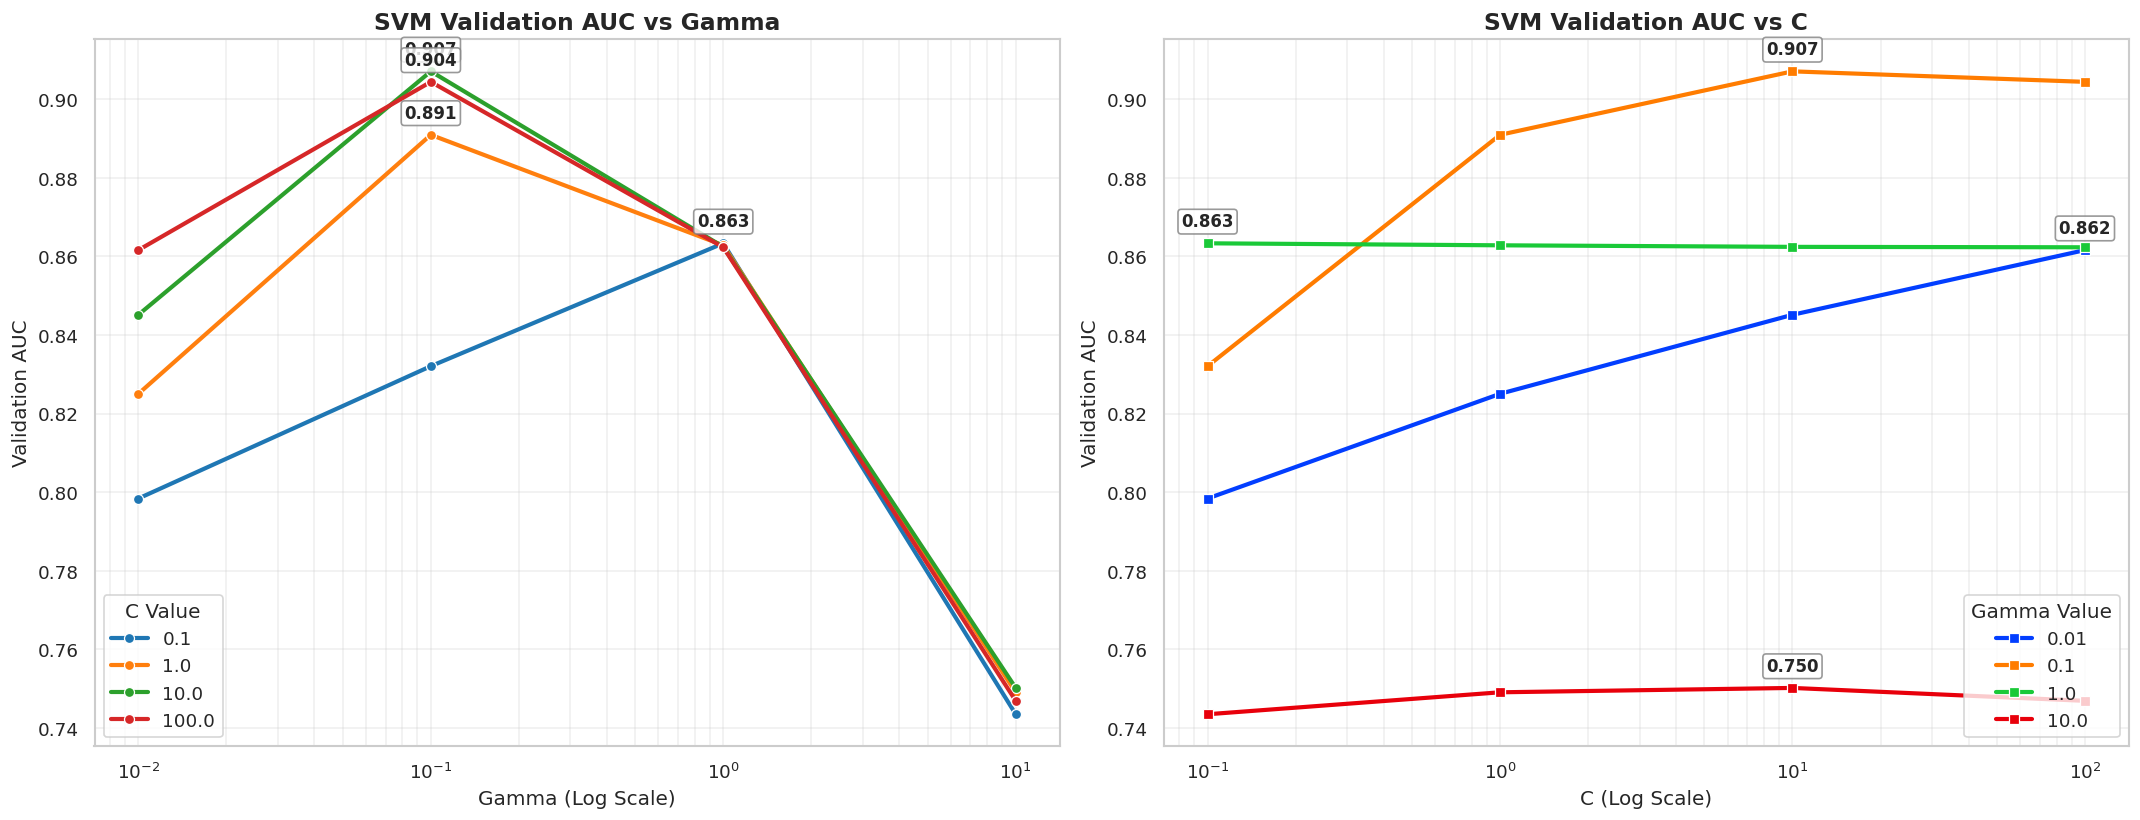

In [2]:
import cudf
from cuml.svm import SVC
from cuml.preprocessing import StandardScaler
from cuml.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import os
import time

train_file = "extracted_features_train.csv"
test_file  = "extracted_features_test.csv"

if not os.path.exists(train_file) or not os.path.exists(test_file):
    raise FileNotFoundError("Please upload both train and test CSV files")

print("--- Loading Data ---")
df_train = cudf.read_csv(train_file).dropna()
df_test  = cudf.read_csv(test_file).dropna()

X = df_train.drop(columns=['target'])
y = df_train['target'].astype('float32')

X_test = df_test.drop(columns=['target'])
y_test = df_test['target'].astype('float32')


print("--- Splitting Data ---")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


print("--- Scaling Data ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


C_range = [0.1, 1, 10, 100]
Gamma_range = [0.01, 0.1, 1, 10]

results_list = []
total_runs = len(C_range) * len(Gamma_range)
run_counter = 0

print(f"\n--- Starting SVM Grid Search ({total_runs} combinations) ---")
print("-" * 60)

for c in C_range:
    for g in Gamma_range:
        run_counter += 1
        start_time = time.time()

        print(f"Run [{run_counter}/{total_runs}] : C={c:<5} Gamma={g:<5} ...", end=" ", flush=True)

        model = SVC(kernel='rbf', C=c, gamma=g, probability=True)
        model.fit(X_train_scaled, y_train)

        
        val_preds = model.predict_proba(X_val_scaled)
        preds_cpu = val_preds.to_numpy()[:, 1] if hasattr(val_preds, 'to_numpy') else val_preds
        y_val_cpu = y_val.to_numpy() if hasattr(y_val, 'to_numpy') else y_val

        val_auc = roc_auc_score(y_val_cpu, preds_cpu)

        elapsed = time.time() - start_time
        print(f"DONE! AUC: {val_auc:.4f} ({elapsed:.2f}s)")

        results_list.append({'C': c, 'Gamma': g, 'AUC': val_auc})

print("-" * 60)
print("Grid Search Complete.")


df_res = pd.DataFrame(results_list)
df_res['C_Label']     = df_res['C'].astype(str)
df_res['Gamma_Label'] = df_res['Gamma'].astype(str)


def annotate_peaks(data, x_col, y_col, hue_col, ax):
    for group in data[hue_col].unique():
        subset = data[data[hue_col] == group]
        peak = subset.loc[subset[y_col].idxmax()]
        ax.annotate(f'{peak[y_col]:.3f}',
                    xy=(peak[x_col], peak[y_col]),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, edgecolor='gray'))


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)


sns.lineplot(data=df_res, x='Gamma', y='AUC', hue='C_Label',
             palette='tab10', marker='o', linewidth=2.5, ax=axes[0])
annotate_peaks(df_res, 'Gamma', 'AUC', 'C_Label', axes[0])
axes[0].set_xscale('log')
axes[0].set_title("SVM Validation AUC vs Gamma", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Gamma (Log Scale)", fontsize=12)
axes[0].set_ylabel("Validation AUC", fontsize=12)
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(title='C Value', loc='lower left')


sns.lineplot(data=df_res, x='C', y='AUC', hue='Gamma_Label',
             palette='bright', marker='s', linewidth=2.5, ax=axes[1])
annotate_peaks(df_res, 'C', 'AUC', 'Gamma_Label', axes[1])
axes[1].set_xscale('log')
axes[1].set_title("SVM Validation AUC vs C", fontsize=14, fontweight='bold')
axes[1].set_xlabel("C (Log Scale)", fontsize=12)
axes[1].set_ylabel("Validation AUC", fontsize=12)
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(title='Gamma Value', loc='lower right')

plt.tight_layout()
plt.savefig("svm_gpu_gridsearch.png")
print("\nGraphs saved as 'svm_gpu_gridsearch.png'")
plt.show()

--- Starting XGBoost GPU Grid Search ---
LR: 0.01 | Trees: 100 | AUC: 0.7618
LR: 0.01 | Trees: 300 | AUC: 0.7858
LR: 0.01 | Trees: 500 | AUC: 0.7955
LR: 0.01 | Trees: 1000 | AUC: 0.8094
LR: 0.05 | Trees: 100 | AUC: 0.7955
LR: 0.05 | Trees: 300 | AUC: 0.8179
LR: 0.05 | Trees: 500 | AUC: 0.8292
LR: 0.05 | Trees: 1000 | AUC: 0.8465
LR: 0.1 | Trees: 100 | AUC: 0.8103
LR: 0.1 | Trees: 300 | AUC: 0.8354
LR: 0.1 | Trees: 500 | AUC: 0.8482
LR: 0.1 | Trees: 1000 | AUC: 0.8662
LR: 0.2 | Trees: 100 | AUC: 0.8238
LR: 0.2 | Trees: 300 | AUC: 0.8503
LR: 0.2 | Trees: 500 | AUC: 0.8638
LR: 0.2 | Trees: 1000 | AUC: 0.8818


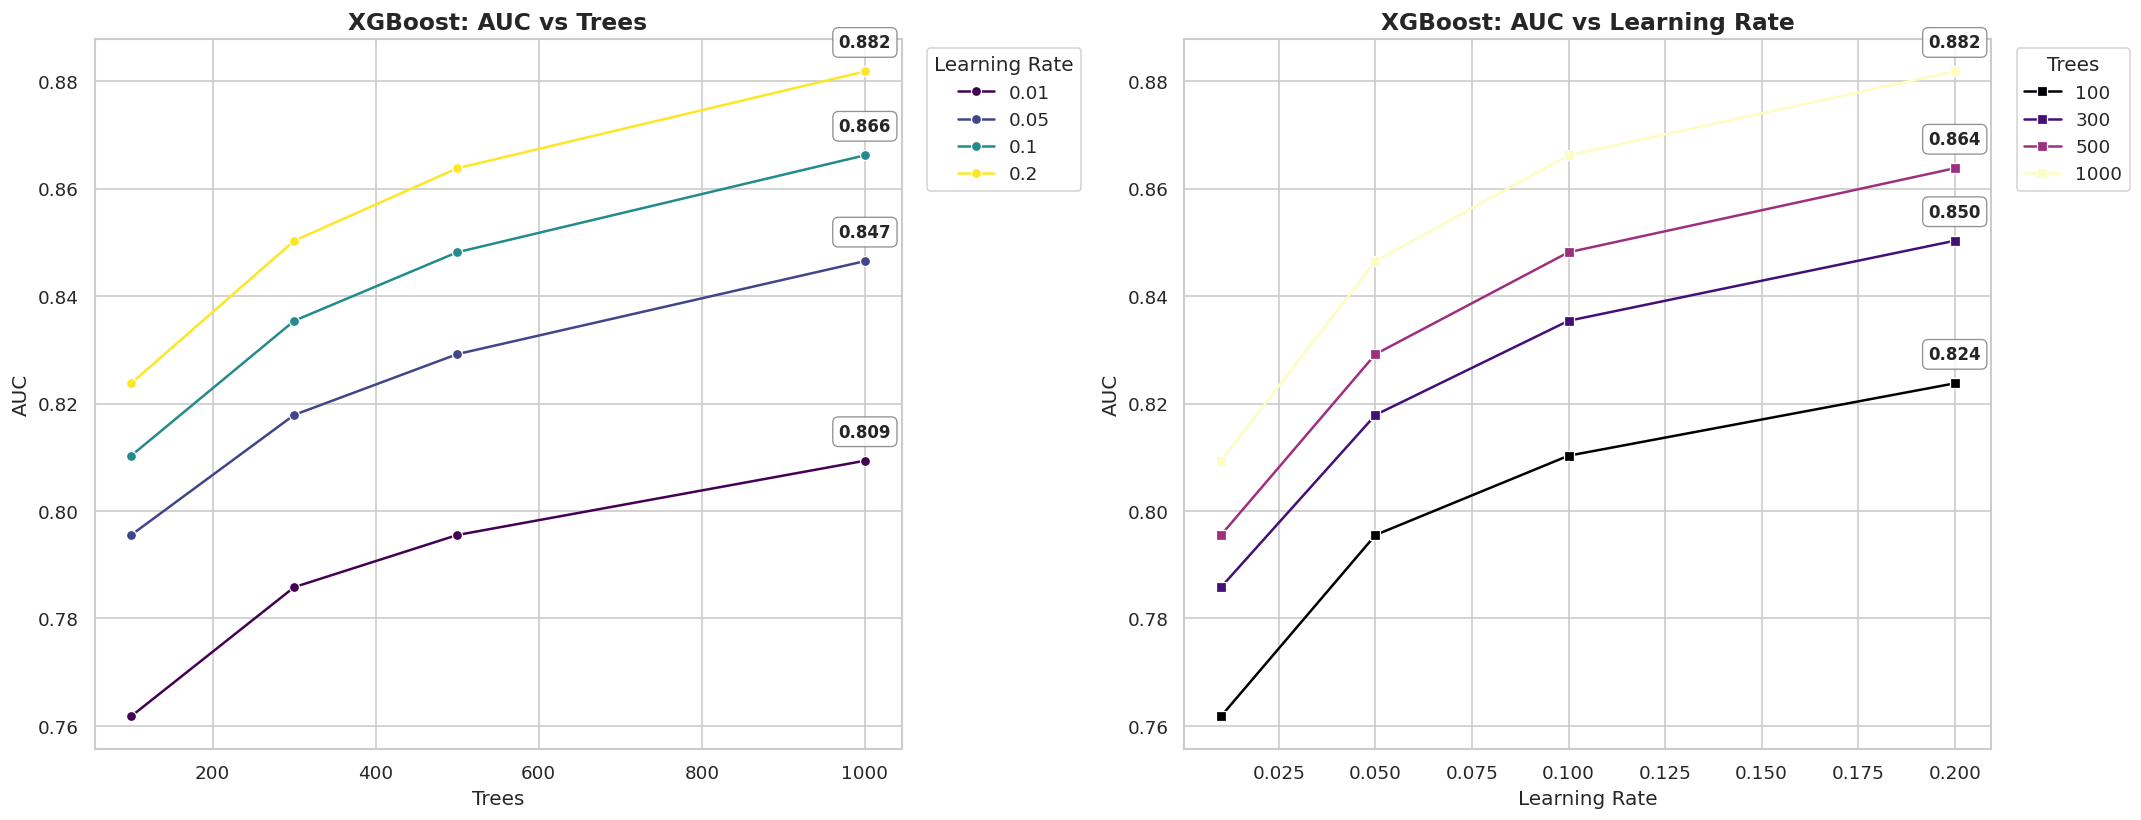

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


lr_range = [0.01, 0.05, 0.1, 0.2]
n_trees_xgb = [100, 300, 500, 1000]
xgb_results = []

print("--- Starting XGBoost GPU Grid Search ---")
for lr in lr_range:
    for n in n_trees_xgb:
        model = XGBClassifier(n_estimators=n, learning_rate=lr, 
                              tree_method='hist', device='cuda', 
                              random_state=42, eval_metric='auc')
        model.fit(X_train_scaled, y_train)
        
        probs = model.predict_proba(X_val_scaled)[:, 1]
        y_val_cpu = y_val.to_numpy() if hasattr(y_val, 'to_numpy') else y_val
        auc = roc_auc_score(y_val_cpu, probs)
        xgb_results.append({'Learning Rate': lr, 'Trees': n, 'AUC': auc})
        print(f"LR: {lr} | Trees: {n} | AUC: {auc:.4f}")

df_xgb = pd.DataFrame(xgb_results)


def annotate_max(data, x_col, y_col, hue_col, ax):
    for group in data[hue_col].unique():
        subset = data[data[hue_col] == group]
        peak = subset.loc[subset[y_col].idxmax()]
        ax.annotate(f'{peak[y_col]:.3f}',
                    xy=(peak[x_col], peak[y_col]),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", lw=0.8, alpha=0.85))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)


sns.lineplot(data=df_xgb, x='Trees', y='AUC', hue='Learning Rate', palette='viridis', marker='o', ax=axes[0])
annotate_max(df_xgb, 'Trees', 'AUC', 'Learning Rate', axes[0])
axes[0].set_title("XGBoost: AUC vs Trees", fontsize=14, fontweight='bold')
axes[0].legend(title="Learning Rate", bbox_to_anchor=(1.02, 1), loc='upper left')


sns.lineplot(data=df_xgb, x='Learning Rate', y='AUC', hue='Trees', palette='magma', marker='s', ax=axes[1])
annotate_max(df_xgb, 'Learning Rate', 'AUC', 'Trees', axes[1])
axes[1].set_title("XGBoost: AUC vs Learning Rate", fontsize=14, fontweight='bold')
axes[1].legend(title="Trees", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("xgboost_lr_trees_gridsearch.png", dpi=150, bbox_inches='tight')
plt.show()


--- Starting Random Forest GPU Grid Search ---
Depth: 10 | Trees: 100 | AUC: 0.7975
Depth: 10 | Trees: 300 | AUC: 0.7979
Depth: 10 | Trees: 500 | AUC: 0.7981
Depth: 10 | Trees: 1000 | AUC: 0.7983
Depth: 15 | Trees: 100 | AUC: 0.8476
Depth: 15 | Trees: 300 | AUC: 0.8482
Depth: 15 | Trees: 500 | AUC: 0.8485
Depth: 15 | Trees: 1000 | AUC: 0.8488
Depth: 20 | Trees: 100 | AUC: 0.8828
Depth: 20 | Trees: 300 | AUC: 0.8842
Depth: 20 | Trees: 500 | AUC: 0.8846
Depth: 20 | Trees: 1000 | AUC: 0.8849
Depth: 25 | Trees: 100 | AUC: 0.8953
Depth: 25 | Trees: 300 | AUC: 0.8970
Depth: 25 | Trees: 500 | AUC: 0.8975
Depth: 25 | Trees: 1000 | AUC: 0.8977


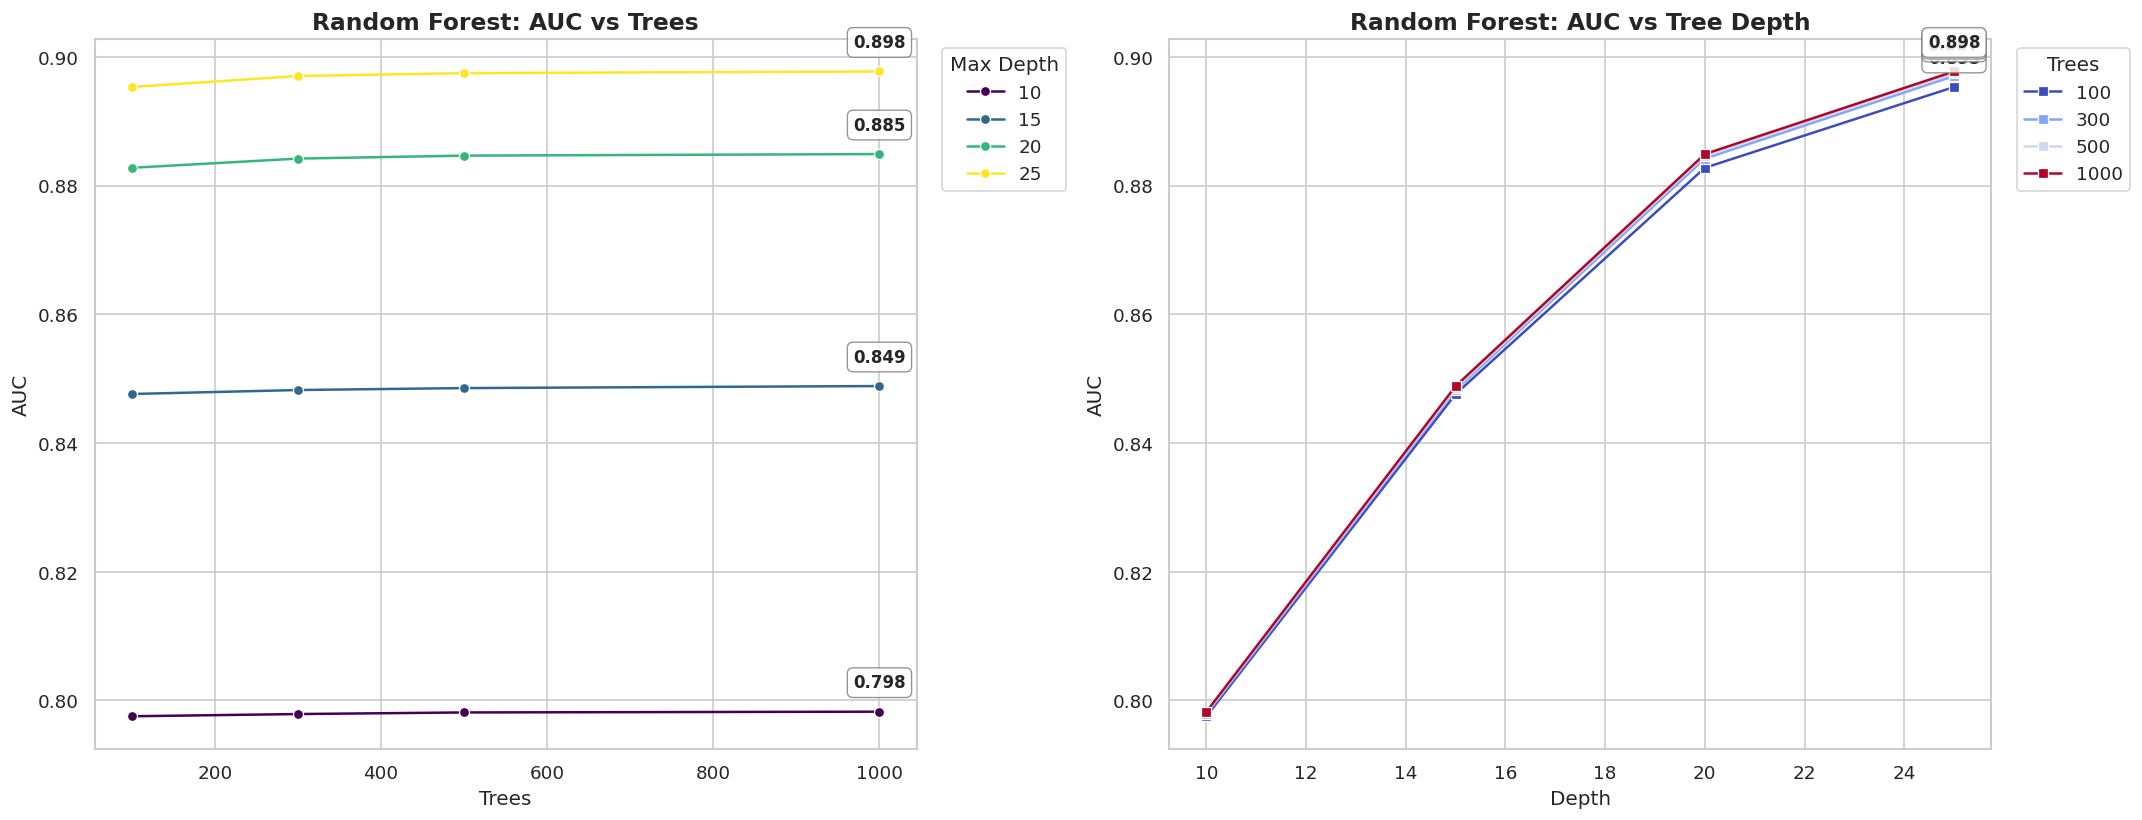

In [14]:
from cuml.ensemble import RandomForestClassifier as cuRF


depth_range = [10, 15, 20, 25] 
n_trees_rf = [100, 300, 500, 1000]
rf_results = []

print("\n--- Starting Random Forest GPU Grid Search ---")
for d in depth_range:
    for n in n_trees_rf:
        model = cuRF(n_estimators=n, max_depth=d, random_state=42)
        model.fit(X_train_scaled, y_train)
        
        probs = model.predict_proba(X_val_scaled)[1].to_numpy()
        y_val_cpu = y_val.to_numpy() if hasattr(y_val, 'to_numpy') else y_val
        auc = roc_auc_score(y_val_cpu, probs)
        rf_results.append({'Depth': d, 'Trees': n, 'AUC': auc})
        print(f"Depth: {d} | Trees: {n} | AUC: {auc:.4f}")

df_rf = pd.DataFrame(rf_results)


fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)


sns.lineplot(data=df_rf, x='Trees', y='AUC', hue='Depth', palette='viridis', marker='o', ax=axes[0])
annotate_max(df_rf, 'Trees', 'AUC', 'Depth', axes[0])
axes[0].set_title("Random Forest: AUC vs Trees", fontsize=14, fontweight='bold')
axes[0].legend(title="Max Depth", bbox_to_anchor=(1.02, 1), loc='upper left')


sns.lineplot(data=df_rf, x='Depth', y='AUC', hue='Trees', palette='coolwarm', marker='s', ax=axes[1])
annotate_max(df_rf, 'Depth', 'AUC', 'Trees', axes[1])
axes[1].set_title("Random Forest: AUC vs Tree Depth", fontsize=14, fontweight='bold')
axes[1].legend(title="Trees", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("rf_depth_trees_gridsearch.png", dpi=150, bbox_inches='tight')
plt.show()